# Firn temperature validation

Compares three estimates of ΔT_firn = T_shallow − T_maat for each elevation band:

1. **Observed** (`dT_obs`): glenglat borehole profiles (ground truth)
2. **Initialized** (`dT_init`): C&P calibration from glenglat notebook 02, applied per band in `initialise_firnicetemp_spinup.pro`
3. **Model-derived** (`dT_model`): implied by GloGEM's refreezing fluxes via (Lf/ci)·f_rf, written by `write_firnicetemp_validation.pro`

Re-run this notebook after any model change to check for improvement.  
Edit `FIRNICE_DIR` in the config cell to point to the desired run output.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from cmcrameri import cm as cmc

# ── Paths — edit FIRNICE_DIR to validate a different run ───────────────────
BASE_DIR    = Path('/home/jabeer/projects/glogemflow_development')
FIRNICE_DIR = Path('/scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development'
                   '/SwissAlps_firnicetemp_ensemble/monthly/CentralEurope'
                   '/files/BCC-CSM2-MR/ssp126/firnice_temperature')
DATA_DIR    = BASE_DIR / 'glogemflow_icetemp/data'
FIG_DIR     = BASE_DIR / 'glogemflow_icetemp/figures'
FIG_DIR.mkdir(exist_ok=True)

# ── Physical constants ─────────────────────────────────────────────────────
Lf = 334000.   # J/kg  latent heat of fusion
ci = 2009.     # J/(kg K)  specific heat of ice

# ── Glacier name labels ────────────────────────────────────────────────────
GLACIER_NAMES = {
    '01225': 'Gornergletscher',
    '01230': 'Grenzgletscher',
    '02596': 'Great Aletsch',
    '02611': 'Fieschergletscher',
    '00773': 'Glacier des Bossons',
    '00777': 'Tête Rousse',
    '02216': 'Morteratsch',
    '02103': 'Corvatsch',
}

In [32]:
def load_validation_files(firnice_dir):
    """Load all firnice_temp_validation_*.dat files into a single DataFrame."""
    records = []
    for f in sorted(Path(firnice_dir).glob('firnice_temp_validation_*.dat')):
        glacier_id = f.stem.replace('firnice_temp_validation_', '')
        with open(f) as fh:
            lines = [l.strip() for l in fh if not l.startswith('#') and l.strip()]
        for line in lines:
            vals = line.split()
            if len(vals) == 8:
                records.append(dict(
                    glacier_id=glacier_id,
                    elev=int(vals[0]),
                    firn=int(vals[1]),
                    t_amp=float(vals[2]),
                    dT_init=float(vals[3]),
                    f_rf=float(vals[4]),
                    dT_model=float(vals[5]),
                    residual=float(vals[6]),
                    T_sfc=float(vals[7]),
                ))
    return pd.DataFrame(records)


val = load_validation_files(FIRNICE_DIR)
val['glacier_name'] = val['glacier_id'].map(GLACIER_NAMES)

# Summary: firn bands only
firn = val[val['firn'] == 1].copy()
summary = (
    firn.groupby('glacier_id')
    .agg(
        name=('glacier_name', 'first'),
        n_bands=('elev', 'count'),
        elev_min=('elev', 'min'),
        elev_max=('elev', 'max'),
        t_amp=('t_amp', 'mean'),
        dT_init=('dT_init', 'first'),
        dT_model_mean=('dT_model', 'mean'),
        residual_mean=('residual', 'mean'),
    )
    .round(2)
)
print(summary.to_string())

                           name  n_bands  elev_min  elev_max  t_amp  dT_init  dT_model_mean  residual_mean
glacier_id                                                                                                
00773       Glacier des Bossons      161      3175      4775  15.38      4.4          48.33          45.08
00777               Tête Rousse       29      3096      3292  15.38      4.4           7.25           2.85
01225           Gornergletscher      143      3095      4515  15.33      4.4          49.07          45.26
01230            Grenzgletscher      173      2765      4485  15.33      4.4          46.44          42.46
02103                 Corvatsch       35      3015      3355  15.63      4.4          13.68           9.28
02216               Morteratsch      104      2855      3885  15.63      4.4          34.44          30.04
02596             Great Aletsch       82      3145      3955  15.63      4.4          32.01          27.61
02611         Fieschergletscher      

In [33]:
# Load glenglat and match to RGI7 IDs
profiles = pd.read_csv(DATA_DIR / 'glenglat_profiles_derived.csv')
borehole = pd.read_csv(BASE_DIR / 'glogemflow_icetemp/glenglat/data/borehole.csv')
lookup   = pd.read_csv(DATA_DIR / 'rgi7_centraleurope_glims_lookup.csv')

# Build borehole → glacier_id mapping via GLIMS
lookup['glacier_id'] = lookup['rgi7_glogem'].str.split('.').str[-1]
bh_map = (
    borehole[['id', 'glims_id']]
    .merge(lookup[['glims_id', 'glacier_id']], on='glims_id', how='left')
    .rename(columns={'id': 'borehole_id'})
)

# Attach RGI7 glacier_id to profiles
obs = profiles.merge(bh_map[['borehole_id', 'glacier_id']], on='borehole_id', how='left')

# Filter: CentralEurope, accumulation zone, non-near-PMP, non-ablation
obs_filt = obs[
    (obs['glogem_region'] == 'CentralEurope') &
    (obs['mass_balance_area'] == 'accumulation') &
    (obs['T_shallow'] < -0.5)
].copy()

print(f'{len(obs_filt)} filtered glenglat profiles in CentralEurope accumulation zone')
print(obs_filt.groupby(['glacier_id', 'glacier_name'])['dT_firn'].count().to_string())

100 filtered glenglat profiles in CentralEurope accumulation zone
glacier_id  glacier_name          
00773       Glacier des Bossons        7
00774       Glacier des Bossons        1
00777       Glacier de Tête Rousse     3
01225       Grenzgletscher            35
01230       Grenzgletscher             9
02103       Vadret dal Corvatsch      31
02216       Vadret da Morteratsch      1
02596       Jungfraufirn              10
02611       Fieschergletscher          3


## Figure 1: Per-glacier ΔT_firn elevation profiles

Each panel shows one glacier.  
**Blue line**: dT_model — ΔT_firn implied by GloGEM's accumulated refreezing fluxes (Lf/ci · f_rf), firn bands only.  
**Orange dashed**: dT_init — the C&P calibration applied at spin-up (constant per climatic regime).  
**Red circles**: glenglat observed ΔT_firn at borehole elevations.

A well-calibrated initialization has `dT_init ≈ dT_obs`. The gap between `dT_model` and `dT_init`/`dT_obs` indicates the degree to which GloGEM's refreezing module over- or under-estimates the latent heat source in the firn.

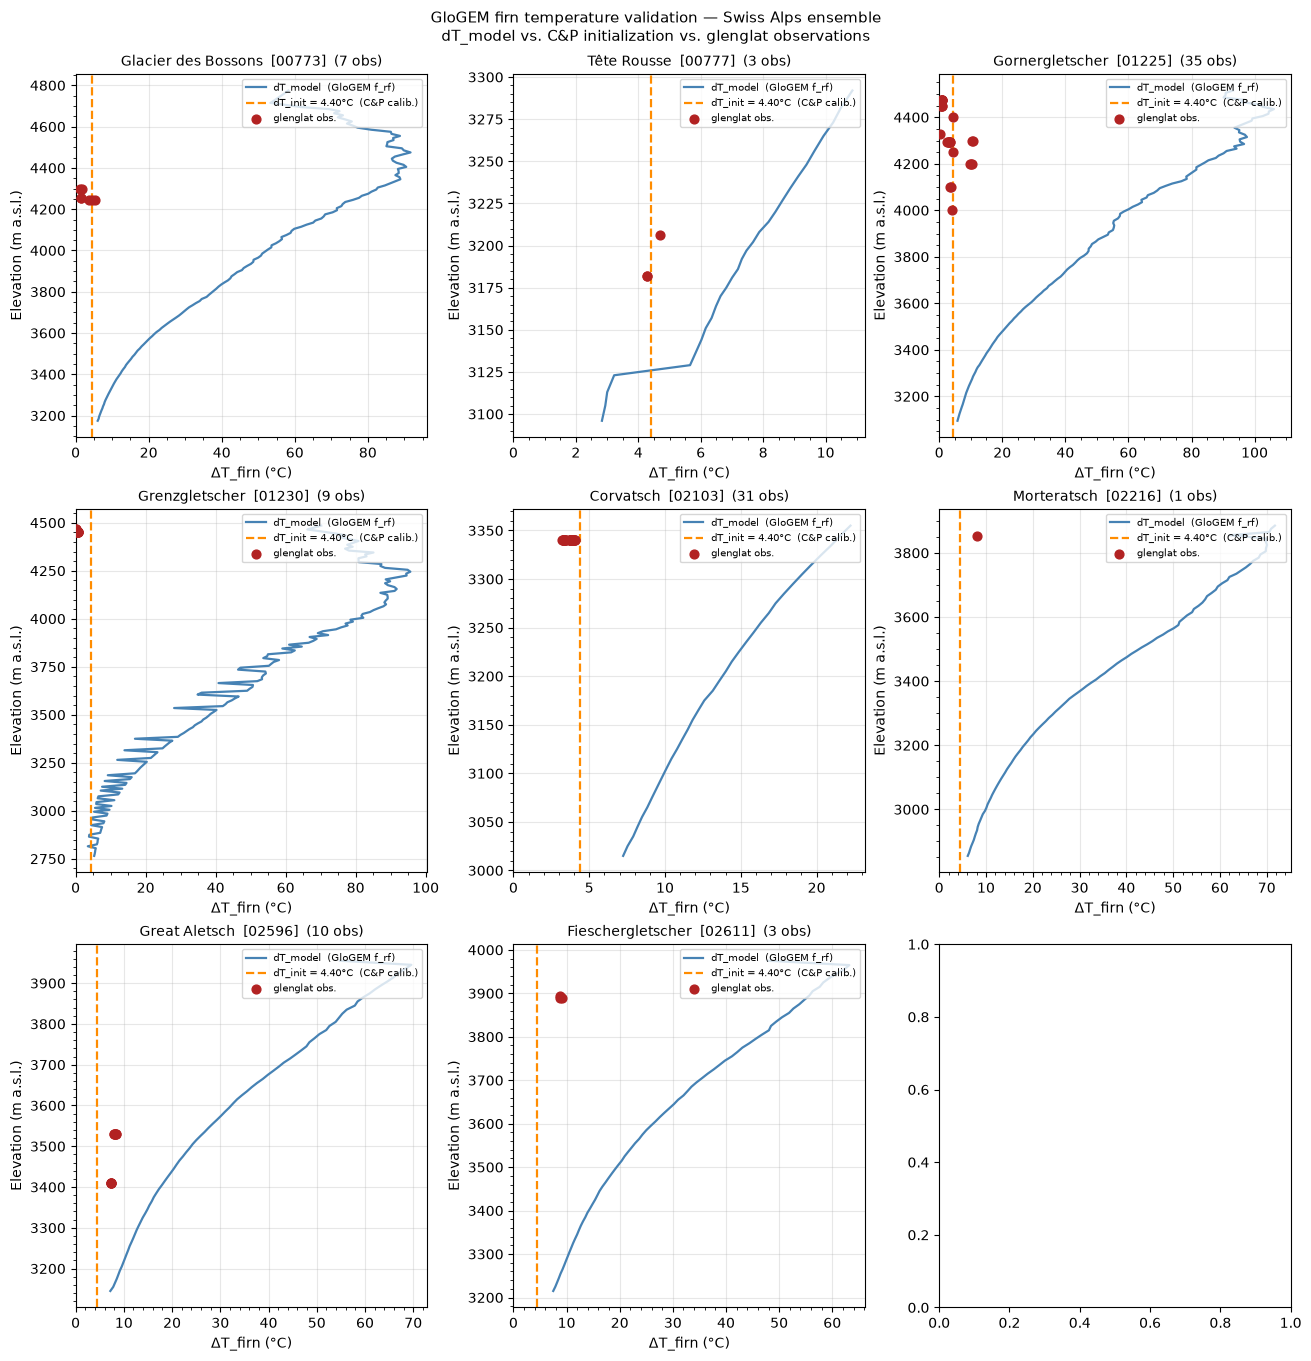

Saved fig_firnice_01_elevation_profiles.pdf


In [34]:
# Glaciers with firn bands (exclude 00777 / Tête Rousse — no firn bands)
plot_ids = [g for g in summary.index if summary.loc[g, 'n_bands'] > 0]

ncols = 3
nrows = int(np.ceil(len(plot_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows),
                         sharey=False, constrained_layout=True)
axes = axes.flat

for ax, gid in zip(axes, plot_ids):
    gdf = firn[firn['glacier_id'] == gid].sort_values('elev')
    obs_g = obs_filt[obs_filt['glacier_id'] == gid]

    # dT_model profile
    ax.plot(gdf['dT_model'], gdf['elev'], color='steelblue', lw=1.6,
            label='dT_model  (GloGEM f_rf)')

    # dT_init — constant per band, draw as vertical dashed line
    if len(gdf) > 0:
        dt_init_val = gdf['dT_init'].iloc[0]
        ax.axvline(dt_init_val, color='darkorange', lw=1.6, ls='--',
                   label=f'dT_init = {dt_init_val:.2f}°C  (C&P calib.)')

    # glenglat observations
    if len(obs_g) > 0:
        ax.scatter(obs_g['dT_firn'], obs_g['elevation'],
                   color='firebrick', s=40, zorder=5, label='glenglat obs.')

    # Formatting
    name = GLACIER_NAMES.get(gid, gid)
    n_obs = len(obs_g)
    ax.set_title(f'{name}  [{gid}]  ({n_obs} obs)', fontsize=10)
    ax.set_xlabel('ΔT_firn (°C)')
    ax.set_ylabel('Elevation (m a.s.l.)')
    ax.set_xlim(left=0)
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

# Hide unused panels
for ax in list(axes)[len(plot_ids):]:
    ax.set_visible(False)

fig.suptitle('GloGEM firn temperature validation — Swiss Alps ensemble\n'
             'dT_model vs. C&P initialization vs. glenglat observations',
             fontsize=11)
fig.savefig(FIG_DIR / 'fig_firnice_01_elevation_profiles.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_firnice_01_elevation_profiles.pdf')

## Figure 2: Calibration quality — observed vs. initialized ΔT_firn

Scatter of glenglat observed ΔT_firn versus the C&P-initialized ΔT_firn at the closest matching elevation band. Points on the 1:1 line indicate perfect agreement. This is the key test of whether the glenglat calibration reproduces individual borehole observations.

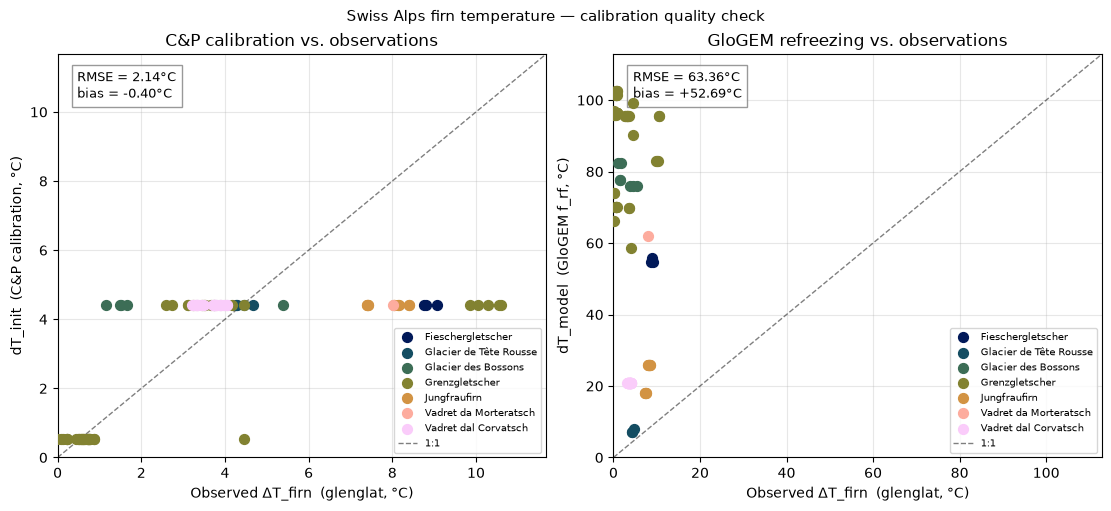

Saved fig_firnice_02_calib_scatter.pdf


In [35]:
# For each glenglat profile match dT_init by nearest elevation band
rows = []
for _, row in obs_filt.iterrows():
    gid = row['glacier_id']
    if pd.isna(gid):
        continue
    gdf = firn[firn['glacier_id'] == gid]
    if len(gdf) == 0:
        continue
    # nearest elevation band
    idx = (gdf['elev'] - row['elevation']).abs().idxmin()
    rows.append({
        'glacier_id': gid,
        'glacier_name': row['glacier_name'],
        'elev_obs': row['elevation'],
        'elev_band': gdf.loc[idx, 'elev'],
        'dT_obs': row['dT_firn'],
        'dT_init': gdf.loc[idx, 'dT_init'],
        'dT_model': gdf.loc[idx, 'dT_model'],
    })

matched = pd.DataFrame(rows)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

glaciers_uniq = matched['glacier_name'].unique()
palette = {g: cmc.batlow(i / max(len(glaciers_uniq) - 1, 1))
           for i, g in enumerate(sorted(glaciers_uniq))}

xy_max = max(matched['dT_obs'].max(), matched['dT_init'].max(),
             matched['dT_model'].max()) * 1.1

for ax, (y_col, y_label, title) in zip(axes, [
    ('dT_init',  'dT_init  (C&P calibration, °C)',  'C&P calibration vs. observations'),
    ('dT_model', 'dT_model  (GloGEM f_rf, °C)',     'GloGEM refreezing vs. observations'),
]):
    for gname in sorted(glaciers_uniq):
        sub = matched[matched['glacier_name'] == gname]
        ax.scatter(sub['dT_obs'], sub[y_col],
                   color=palette[gname], s=50, label=gname, zorder=4)

    lim = (0, max(matched['dT_obs'].max(), matched[y_col].max()) * 1.1)
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5, label='1:1')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Observed ΔT_firn  (glenglat, °C)')
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

    # RMSE
    rmse = np.sqrt(((matched[y_col] - matched['dT_obs'])**2).mean())
    bias = (matched[y_col] - matched['dT_obs']).mean()
    ax.text(0.04, 0.96, f'RMSE = {rmse:.2f}°C\nbias = {bias:+.2f}°C',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(fc='white', ec='grey', alpha=0.8))

fig.suptitle('Swiss Alps firn temperature — calibration quality check', fontsize=11)
fig.savefig(FIG_DIR / 'fig_firnice_02_calib_scatter.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_firnice_02_calib_scatter.pdf')

## Figure 3: GloGEM refreezing fraction f_rf vs. elevation

The implied refreezing fraction f_rf = refreeze_sum / melt_sum per band (accumulated over the full simulation period). Compared to the f_rf implied by glenglat observations: f_rf_obs = dT_obs · ci / Lf.

A large gap between the two confirms that GloGEM's refreezing module operates at a different magnitude than what the firn temperature signal integrates over long timescales.

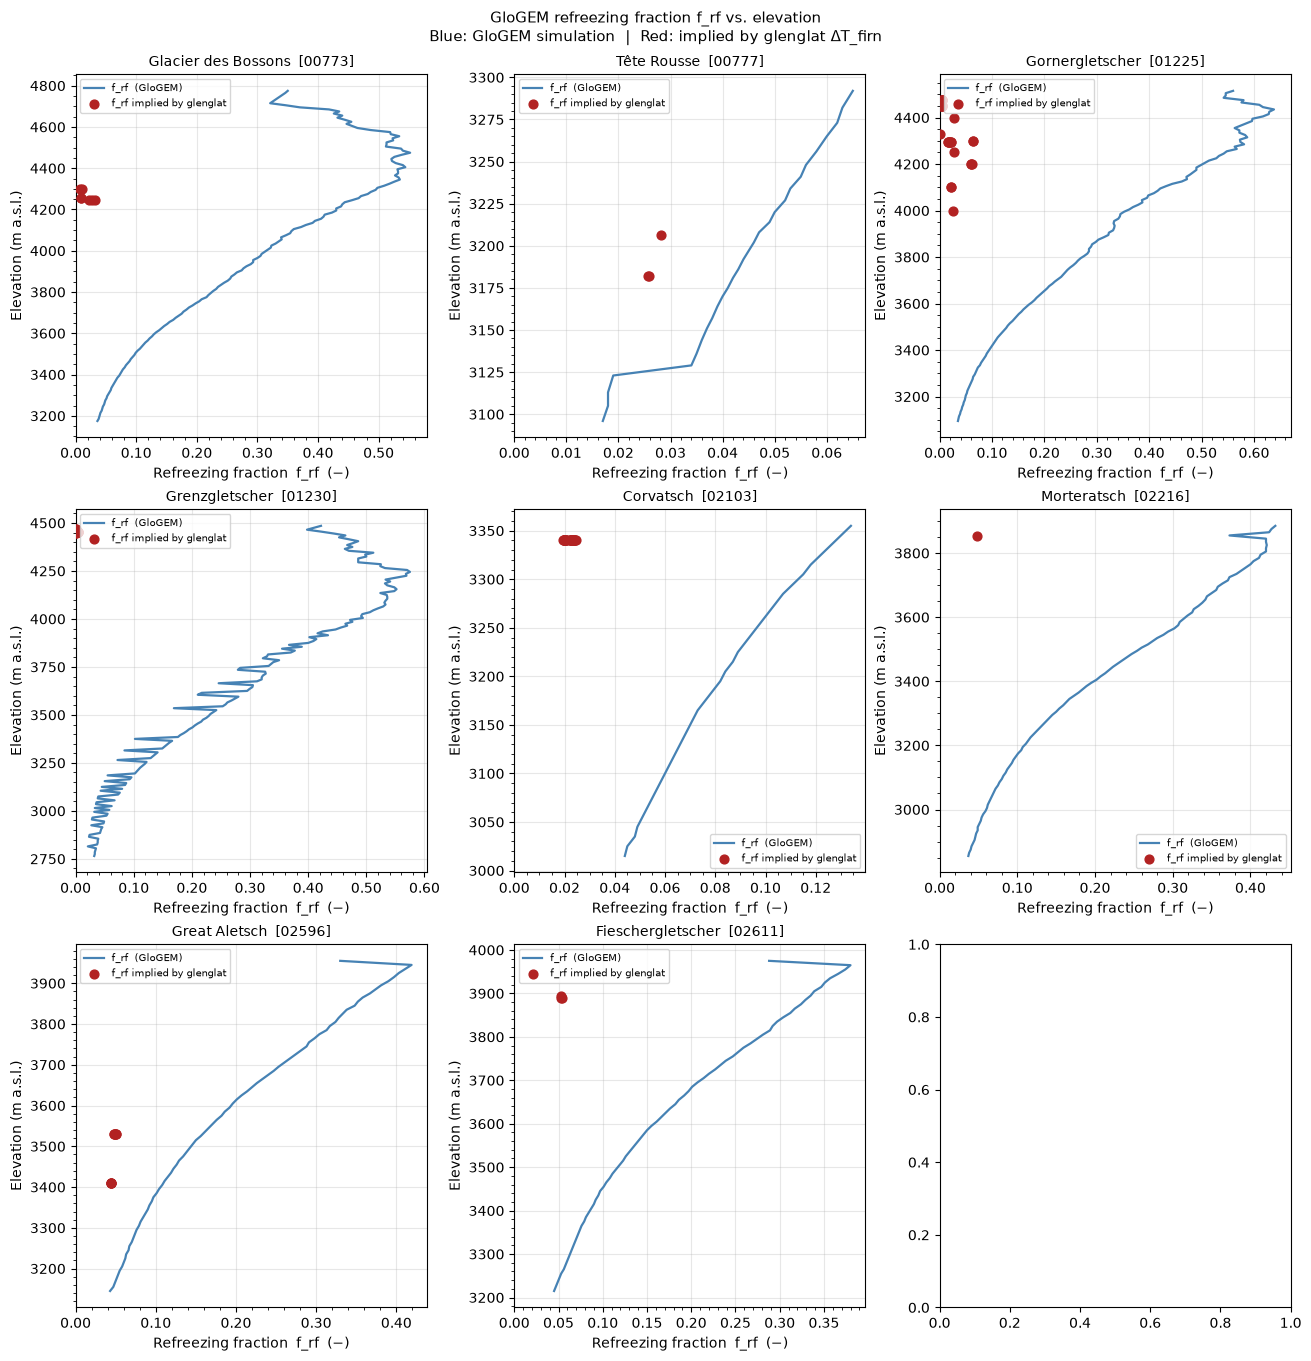

Saved fig_firnice_03_frf_profiles.pdf


In [37]:
# Implied f_rf from glenglat observations
obs_filt = obs_filt.copy()
obs_filt['f_rf_obs'] = obs_filt['dT_firn'] * ci / Lf

ncols = 3
nrows = int(np.ceil(len(plot_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows),
                         sharey=False, constrained_layout=True)
axes = axes.flat

for ax, gid in zip(axes, plot_ids):
    gdf = firn[firn['glacier_id'] == gid].sort_values('elev')
    obs_g = obs_filt[obs_filt['glacier_id'] == gid]

    ax.plot(gdf['f_rf'], gdf['elev'], color='steelblue', lw=1.6,
            label='f_rf  (GloGEM)')

    if len(obs_g) > 0:
        ax.scatter(obs_g['f_rf_obs'], obs_g['elevation'],
                   color='firebrick', s=40, zorder=5,
                   label=f'f_rf implied by glenglat')

    name = GLACIER_NAMES.get(gid, gid)
    ax.set_title(f'{name}  [{gid}]', fontsize=10)
    ax.set_xlabel('Refreezing fraction  f_rf  (−)')
    ax.set_ylabel('Elevation (m a.s.l.)')
    ax.set_xlim(left=0)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

for ax in list(axes)[len(plot_ids):]:
    ax.set_visible(False)

fig.suptitle('GloGEM refreezing fraction f_rf vs. elevation\n'
             'Blue: GloGEM simulation  |  Red: implied by glenglat ΔT_firn',
             fontsize=11)
fig.savefig(FIG_DIR / 'fig_firnice_03_frf_profiles.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_firnice_03_frf_profiles.pdf')

## Summary table

Per-glacier statistics for firn bands. `residual` = dT_model − dT_init. A large positive residual means GloGEM's refreezing overestimates the latent heat source relative to the glenglat calibration.

In [38]:
# Extended summary including glenglat comparison at matched elevations
obs_stats = (
    matched.groupby('glacier_id')
    .agg(
        n_obs=('dT_obs', 'count'),
        dT_obs_mean=('dT_obs', 'mean'),
        dT_obs_std=('dT_obs', 'std'),
        rmse_init=('dT_obs', lambda x: np.sqrt(((matched.loc[x.index,'dT_init'] - x)**2).mean())),
        rmse_model=('dT_obs', lambda x: np.sqrt(((matched.loc[x.index,'dT_model'] - x)**2).mean())),
    )
    .round(2)
)

full_summary = summary.join(obs_stats, how='left')
display_cols = ['name','n_bands','elev_min','elev_max','t_amp',
                'dT_init','dT_model_mean','residual_mean',
                'n_obs','dT_obs_mean','rmse_init','rmse_model']
print(full_summary[display_cols].to_string())

                           name  n_bands  elev_min  elev_max  t_amp  dT_init  dT_model_mean  residual_mean  n_obs  dT_obs_mean  rmse_init  rmse_model
glacier_id                                                                                                                                           
00773       Glacier des Bossons      161      3175      4775  15.38      4.4          48.33          45.08      7         2.77       2.27       75.54
00777               Tête Rousse       29      3096      3292  15.38      4.4           7.25           2.85      3         4.41       0.19        2.89
01225           Gornergletscher      143      3095      4515  15.33      4.4          49.07          45.26     35         2.98       2.41       91.46
01230            Grenzgletscher      173      2765      4485  15.33      4.4          46.44          42.46      9         0.41       0.29       69.74
02103                 Corvatsch       35      3015      3355  15.63      4.4          13.68         

## Figure 4: Temperature vs. depth — borehole profiles

Full T(z) comparison for each glacier. Blue lines show GloGEM's modelled temperature profile at the three IDX-output elevation bands (annual mean 1990–2010). Red scatter shows raw glenglat borehole measurements in the accumulation zone (all available profiles, coloured by borehole elevation).

The firn warming signal (temperature increases toward the surface) should be visible in both observed and modelled curves. A near-isothermal model profile would indicate the C&P warming is too weak or absent.

/tmp/ipykernel_1481372/2067683018.py:30: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array(rows), axis=0)
/tmp/ipykernel_1481372/2067683018.py:30: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array(rows), axis=0)
/tmp/ipykernel_1481372/2067683018.py:30: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array(rows), axis=0)
/tmp/ipykernel_1481372/2067683018.py:30: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array(rows), axis=0)
/tmp/ipykernel_1481372/2067683018.py:30: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array(rows), axis=0)
/tmp/ipykernel_1481372/2067683018.py:30: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array(rows), axis=0)
/tmp/ipykernel_1481372/2067683018.py:30: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array(rows), axis=0)


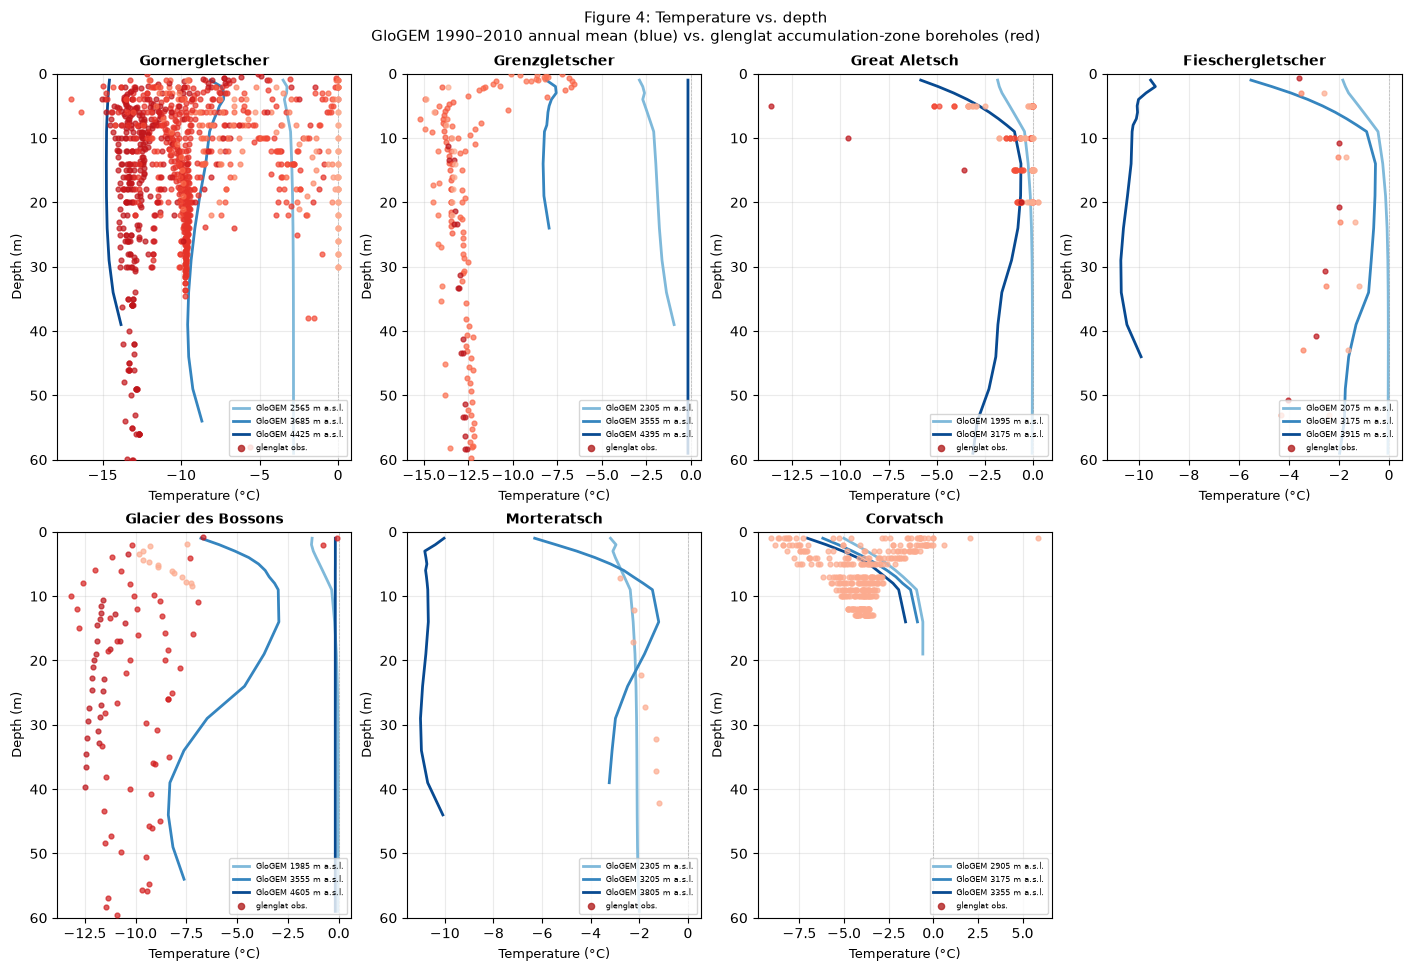

Saved fig_firnice_04_tempprofiles.pdf


In [39]:
import re as _re

GLENGLAT_DIR = BASE_DIR / 'glogemflow_icetemp/glenglat/data'

# Load raw measurement data (depth, temperature per borehole)
_bh   = pd.read_csv(GLENGLAT_DIR / 'borehole.csv')
_meas = pd.read_csv(GLENGLAT_DIR / 'measurement.csv')
_look = pd.read_csv(DATA_DIR / 'rgi7_centraleurope_glims_lookup.csv')
_look['glacier_id'] = _look['rgi7_glogem'].str.split('.').str[-1]
_bh   = _bh.merge(_look[['glims_id', 'glacier_id']], on='glims_id', how='left')


def load_idxprofiles(glacier_id, year_start=1990, year_end=2010):
    """Return {elev_m: (depths, T_mean)} from temp_IDX files, averaged over year range."""
    result = {}
    for idxf in sorted(FIRNICE_DIR.glob(f'temp_ID*_{glacier_id}.dat')):
        with open(idxf) as f:
            lines = f.readlines()
        elev_m = int(_re.search(r'elevation\s+(\d+)', lines[0]).group(1))
        depths = np.array([float(x) for x in lines[1].split()[2:]])
        rows = []
        for line in lines[2:]:
            vals = line.split()
            if len(vals) < 3:
                continue
            yr = int(vals[0])
            if year_start <= yr <= year_end:
                rows.append([np.nan if float(v) < -90 else float(v) for v in vals[2:]])
        if rows:
            T_mean = np.nanmean(np.array(rows), axis=0)
            # guard against header/data length mismatch (depths has 29, data has 30)
            n = min(len(depths), len(T_mean))
            result[elev_m] = (depths[:n], T_mean[:n])
    return result


plot_ids_4 = [g for g in ['01225', '01230', '02596', '02611', '00773', '02216', '02103']
              if list(FIRNICE_DIR.glob(f'temp_ID*_{g}.dat'))]

ncols = 4
nrows = (len(plot_ids_4) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4.8), constrained_layout=True)

MAX_DEPTH = 60  # plot to 60 m — covers the key near-surface firn warming zone

for ax, gid in zip(axes.flat, plot_ids_4):
    # ── GloGEM modelled profiles ───────────────────────────────────────────
    profiles = load_idxprofiles(gid)
    elev_sorted = sorted(profiles)
    colors_m = plt.cm.Blues(np.linspace(0.45, 0.9, max(len(elev_sorted), 1)))
    for col, elev in zip(colors_m, elev_sorted):
        depths, T_mean = profiles[elev]
        mask = ~np.isnan(T_mean) & (depths <= MAX_DEPTH)
        if mask.any():
            ax.plot(T_mean[mask], depths[mask], color=col, lw=2,
                    label=f'GloGEM {elev} m a.s.l.')

    # ── Glenglat observed T(depth) profiles ───────────────────────────────
    bh_acc = _bh[(_bh['glacier_id'] == gid) & (_bh['mass_balance_area'] == 'accumulation')]
    obs_raw = _meas[_meas['borehole_id'].isin(bh_acc['id'])].copy()
    obs_raw = obs_raw[obs_raw['depth'] <= MAX_DEPTH]
    if not obs_raw.empty:
        obs_raw = obs_raw.merge(bh_acc[['id', 'elevation']], left_on='borehole_id',
                                right_on='id', how='left')
        e_min = obs_raw['elevation'].min()
        e_max = max(obs_raw['elevation'].max(), e_min + 1)
        for bid, grp in obs_raw.groupby('borehole_id'):
            frac = (grp['elevation'].iloc[0] - e_min) / (e_max - e_min)
            ax.scatter(grp['temperature'], grp['depth'],
                       color=plt.cm.Reds(0.3 + 0.5 * frac), s=12, alpha=0.7, zorder=5)
        # phantom point for legend
        ax.scatter([], [], color='firebrick', s=20, alpha=0.8, label='glenglat obs.')

    ax.set_ylim(MAX_DEPTH, 0)     # depth increases downward
    ax.axvline(0, color='grey', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlabel('Temperature (°C)', fontsize=9)
    ax.set_ylabel('Depth (m)', fontsize=9)
    ax.set_title(GLACIER_NAMES[gid], fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=6, loc='lower right')

for ax in axes.flat[len(plot_ids_4):]:
    ax.set_visible(False)

fig.suptitle('Figure 4: Temperature vs. depth\n'
             'GloGEM 1990–2010 annual mean (blue) vs. glenglat accumulation-zone boreholes (red)',
             fontsize=11)
fig.savefig(FIG_DIR / 'fig_firnice_04_tempprofiles.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_firnice_04_tempprofiles.pdf')

## Figure 5: Observed vs. modelled absolute firn temperature

Scatter of `T_shallow_obs` (glenglat, measured at `T_shallow_depth` metres) against `T_shallow_model` (GloGEM prediction at the same depth), computed as:

$$T_\text{model}(z) = T_\text{MAAT} + \Delta T_\text{init} \cdot e^{-z / z_0}$$

with $z_0 = 15\,\text{m}$ (C&P e-folding depth) and `T_maat` from the ERA5-forced GloGEM climate. This is a direct check of whether the calibrated initialization produces correct absolute temperatures at the depths where boreholes were measured.

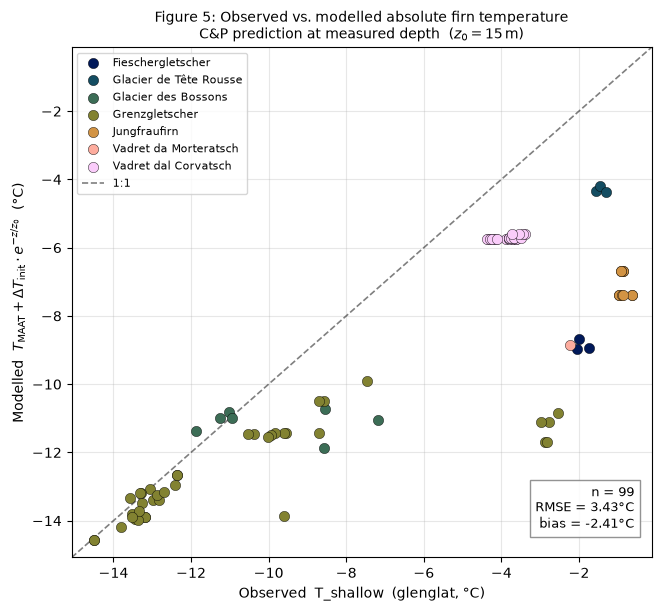

Saved fig_firnice_05_absT_scatter.pdf  (n=99, RMSE=3.43°C, bias=-2.41°C)


In [41]:
z0_firn = 15.0  # C&P e-folding depth (m)

# Build matched table: obs_filt rows ↔ nearest firn band in validation file
rows5 = []
for _, row in obs_filt.iterrows():
    gid = row['glacier_id']
    if pd.isna(gid):
        continue
    gdf = firn[firn['glacier_id'] == gid]
    if len(gdf) == 0:
        continue
    idx = (gdf['elev'] - row['elevation']).abs().idxmin()
    band = gdf.loc[idx]

    z_meas = float(row['T_shallow_depth'])   # depth at which T_shallow was measured

    # T_maat from ERA5 at borehole location (in obs_filt)
    T_maat_era5 = row['T_maat']

    # Predicted T at measurement depth using C&P profile with calibrated dT_init
    T_model_z = T_maat_era5 + band['dT_init'] * np.exp(-z_meas / z0_firn)

    rows5.append({
        'glacier_id':    gid,
        'glacier_name':  row['glacier_name'],
        'elevation':     row['elevation'],
        'z_meas':        z_meas,
        'T_shallow_obs': row['T_shallow'],
        'T_maat_era5':   T_maat_era5,
        'dT_init':       band['dT_init'],
        'T_model_z':     T_model_z,
    })

matched5 = pd.DataFrame(rows5)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 6), constrained_layout=True)

glaciers5 = sorted(matched5['glacier_name'].unique())
palette5  = {g: cmc.batlow(i / max(len(glaciers5) - 1, 1))
             for i, g in enumerate(glaciers5)}

for gname in glaciers5:
    sub = matched5[matched5['glacier_name'] == gname]
    ax.scatter(sub['T_shallow_obs'], sub['T_model_z'],
               color=palette5[gname], s=55, label=gname, zorder=4, edgecolors='k', lw=0.3)

# 1:1 line
all_T = pd.concat([matched5['T_shallow_obs'], matched5['T_model_z']])
t_lo, t_hi = all_T.min() - 0.5, all_T.max() + 0.5
ax.plot([t_lo, t_hi], [t_lo, t_hi], 'k--', lw=1.2, alpha=0.5, label='1:1')

ax.set_xlim(t_lo, t_hi)
ax.set_ylim(t_lo, t_hi)
ax.set_xlabel('Observed  T_shallow  (glenglat, °C)', fontsize=10)
ax.set_ylabel(r'Modelled  $T_\mathrm{MAAT} + \Delta T_\mathrm{init}\cdot e^{-z/z_0}$  (°C)', fontsize=10)
ax.set_title('Figure 5: Observed vs. modelled absolute firn temperature\n'
             r'C&P prediction at measured depth  ($z_0 = 15\,\mathrm{m}$)', fontsize=10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper left')

rmse5 = np.sqrt(((matched5['T_model_z'] - matched5['T_shallow_obs'])**2).mean())
bias5 = (matched5['T_model_z'] - matched5['T_shallow_obs']).mean()
ax.text(0.97, 0.05,
        f'n = {len(matched5)}\nRMSE = {rmse5:.2f}°C\nbias = {bias5:+.2f}°C',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(fc='white', ec='grey', alpha=0.85))

fig.savefig(FIG_DIR / 'fig_firnice_05_absT_scatter.pdf', bbox_inches='tight')
plt.show()
print(f'Saved fig_firnice_05_absT_scatter.pdf  (n={len(matched5)}, RMSE={rmse5:.2f}°C, bias={bias5:+.2f}°C)')

## Figure 6: Observed vs. modelled temperature — all depths and zones

Each point is one borehole × depth measurement (depth ≥ 15 m only), matched to the GloGEM temperature profile at the nearest IDX elevation band (≤ 400 m offset), averaged over the borehole measurement period.

Measurements shallower than 15 m are excluded: at those depths the seasonal cold wave dominates the annual-mean signal and a point-in-time borehole reading cannot be meaningfully compared to the model's annual-mean output. Below 15 m the seasonal amplitude is strongly damped and the comparison captures the long-term thermal state of the firn/ice column.

Depth bins:
- **15–40 m  (firn)**: within the C&P firn-warming influence zone  
- **40–100 m  (deep firn / cold ice)**: conduction-driven approach toward T_maat  
- **> 100 m  (deep ice)**: should approach T_maat or 0 °C at temperate base

Points above the 1:1 line = model too warm; below = model too cold.

Loading IDX profiles…


/tmp/ipykernel_1481372/1537383661.py:23: RuntimeWarning: Mean of empty slice
  annual = {yr: np.nanmean(np.array(v), axis=0) for yr, v in by_yr.items()}


Done.


/tmp/ipykernel_1481372/1537383661.py:35: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(np.array([annual[yr] for yr in yrs]), axis=0)


590 paired points (depth ≥ 15 m)  |  glaciers: 6  |  depth range: 15–126 m


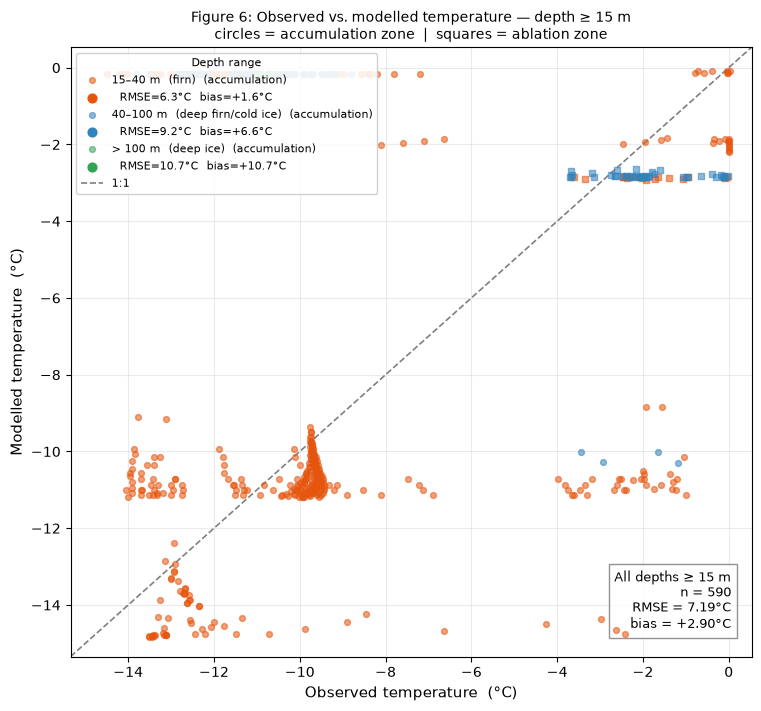

Saved fig_firnice_06_allT_scatter.pdf  (RMSE=7.19°C, bias=+2.90°C, n=590)


In [42]:
GL_DIR = BASE_DIR / 'glogemflow_icetemp/glenglat/data'

# ── Build IDX temperature cache: {gid: {elev_m: (depths, {year: T_annual_mean})}} ──
def build_idx_cache(firnice_dir, glacier_ids):
    cache = {}
    for gid in glacier_ids:
        cache[gid] = {}
        for idxf in sorted(firnice_dir.glob(f'temp_ID*_{gid}.dat')):
            with open(idxf) as f:
                lines = f.readlines()
            elev_m = int(_re.search(r'elevation\s+(\d+)', lines[0]).group(1))
            depths = np.array([float(x) for x in lines[1].split()[2:]])
            by_yr = {}
            for line in lines[2:]:
                vals = line.split()
                if len(vals) < 3: continue
                yr = int(vals[0])
                T = np.array([np.nan if float(v) < -90 else float(v) for v in vals[2:]])
                n = min(len(depths), len(T))
                by_yr.setdefault(yr, []).append(T[:n])
            if by_yr:
                n = min(len(depths), len(next(iter(by_yr.values()))[0]))
                annual = {yr: np.nanmean(np.array(v), axis=0) for yr, v in by_yr.items()}
                cache[gid][elev_m] = (depths[:n], annual)
    return cache

def model_T_at(cache, gid, bh_elev, depth_m, yr_lo, yr_hi, max_elev_offset=400):
    """Return modelled T at (depth_m) from nearest IDX band, averaged over [yr_lo, yr_hi]."""
    if gid not in cache or not cache[gid]: return np.nan
    elev_sorted = sorted(cache[gid])
    nearest = min(elev_sorted, key=lambda e: abs(e - bh_elev))
    if abs(nearest - bh_elev) > max_elev_offset: return np.nan
    depths, annual = cache[gid][nearest]
    yrs = [yr for yr in annual if yr_lo <= yr <= yr_hi] or list(annual)
    T_mean = np.nanmean(np.array([annual[yr] for yr in yrs]), axis=0)
    valid = ~np.isnan(T_mean)
    if valid.sum() < 2 or depth_m > depths[valid].max(): return np.nan
    return float(np.interp(depth_m, depths[valid], T_mean[valid]))

plot_ids_6 = [g for g in ['01225','01230','02596','02611','00773','02216','02103']
              if list(FIRNICE_DIR.glob(f'temp_ID*_{g}.dat'))]

print('Loading IDX profiles…')
cache6 = build_idx_cache(FIRNICE_DIR, plot_ids_6)
print('Done.')

# ── Load and deduplicate measurements (average repeated depth readings over time) ──
bh6   = pd.read_csv(GL_DIR / 'borehole.csv')
meas6 = pd.read_csv(GL_DIR / 'measurement.csv')
lk6   = pd.read_csv(DATA_DIR / 'rgi7_centraleurope_glims_lookup.csv')
lk6['glacier_id'] = lk6['rgi7_glogem'].str.split('.').str[-1]
bh6   = bh6.merge(lk6[['glims_id','glacier_id']], on='glims_id', how='left')
bh6   = bh6[bh6['glacier_id'].isin(plot_ids_6)]

meas_avg = (
    meas6[meas6['borehole_id'].isin(bh6['id'])]
    .groupby(['borehole_id','depth'])['temperature'].mean()
    .reset_index()
)
meas_avg = meas_avg.merge(
    bh6[['id','glacier_id','elevation','mass_balance_area','date_min','date_max']],
    left_on='borehole_id', right_on='id', how='left'
)

# ── Match each measurement to the IDX profile ─────────────────────────────────
rows6 = []
for _, row in meas_avg.iterrows():
    gid  = row['glacier_id']
    if pd.isna(gid): continue
    try:
        yr_lo = max(1940, int(str(row['date_min'])[:4]) - 2)
        yr_hi = min(2100, int(str(row['date_max'])[:4]) + 2)
    except (ValueError, TypeError):
        yr_lo, yr_hi = 1990, 2010
    T_mod = model_T_at(cache6, gid, float(row['elevation']), float(row['depth']),
                       yr_lo, yr_hi)
    if not np.isnan(T_mod):
        rows6.append({
            'glacier_id':   gid,
            'glacier_name': GLACIER_NAMES.get(gid, gid),
            'mba':          str(row['mass_balance_area']),
            'elevation':    float(row['elevation']),
            'depth':        float(row['depth']),
            'T_obs':        float(row['temperature']),
            'T_model':      T_mod,
        })

sc = pd.DataFrame(rows6)

# Remove depths < 15 m: seasonal cold wave dominates the annual mean at shallow depths
# and cannot be meaningfully compared to annual-mean model output
sc = sc[sc['depth'] >= 15.0].copy()

print(f'{len(sc)} paired points (depth ≥ 15 m)  |  glaciers: {sc["glacier_id"].nunique()}  '
      f'|  depth range: {sc["depth"].min():.0f}–{sc["depth"].max():.0f} m')

# ── Plot ───────────────────────────────────────────────────────────────────────
depth_bins   = [15, 40, 100, 400]
depth_labels = ['15–40 m  (firn)', '40–100 m  (deep firn/cold ice)', '> 100 m  (deep ice)']
depth_cmaps  = ['#e6550d', '#3182bd', '#31a354']   # orange / blue / green

mba_markers = {'accumulation': 'o', 'ablation': 's', 'equilibrium': '^'}

fig, ax = plt.subplots(figsize=(7.5, 7), constrained_layout=True)

for dlabel, dcol, d_lo, d_hi in zip(depth_labels, depth_cmaps, depth_bins[:-1], depth_bins[1:]):
    sub = sc[(sc['depth'] >= d_lo) & (sc['depth'] < d_hi)]
    if sub.empty: continue
    for mba, mkr in mba_markers.items():
        s2 = sub[sub['mba'] == mba]
        if s2.empty: continue
        ax.scatter(s2['T_obs'], s2['T_model'], color=dcol, marker=mkr,
                   s=18, alpha=0.55, zorder=4,
                   label=f'{dlabel}  ({mba})' if mba == 'accumulation' else None)
    # RMSE for this depth bin
    rmse_d = np.sqrt(((sub['T_model'] - sub['T_obs'])**2).mean())
    bias_d = (sub['T_model'] - sub['T_obs']).mean()
    ax.scatter([], [], color=dcol, s=40, label=f'  RMSE={rmse_d:.1f}°C  bias={bias_d:+.1f}°C')

# 1:1 line
all_T6 = pd.concat([sc['T_obs'], sc['T_model']])
t6_lo, t6_hi = all_T6.min() - 0.5, all_T6.max() + 0.5
ax.plot([t6_lo, t6_hi], [t6_lo, t6_hi], 'k--', lw=1.2, alpha=0.5, label='1:1')

rmse6 = np.sqrt(((sc['T_model'] - sc['T_obs'])**2).mean())
bias6 = (sc['T_model'] - sc['T_obs']).mean()
ax.text(0.97, 0.04, f'All depths ≥ 15 m\nn = {len(sc)}\nRMSE = {rmse6:.2f}°C\nbias = {bias6:+.2f}°C',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(fc='white', ec='grey', alpha=0.85))

ax.set_xlim(t6_lo, t6_hi); ax.set_ylim(t6_lo, t6_hi)
ax.set_xlabel('Observed temperature  (°C)', fontsize=11)
ax.set_ylabel('Modelled temperature  (°C)', fontsize=11)
ax.set_title('Figure 6: Observed vs. modelled temperature — depth ≥ 15 m\n'
             'circles = accumulation zone  |  squares = ablation zone', fontsize=10)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc='upper left', framealpha=0.9,
          title='Depth range', title_fontsize=8)

fig.savefig(FIG_DIR / 'fig_firnice_06_allT_scatter.pdf', bbox_inches='tight')
plt.show()
print(f'Saved fig_firnice_06_allT_scatter.pdf  (RMSE={rmse6:.2f}°C, bias={bias6:+.2f}°C, n={len(sc)})')